===== DATA LOADED =====
Shape: (3888, 7)
Columns: ['image_path', 'dataset_description', 'category', 'subcategory', 'keywords', 'clean_description', 'final_text']

After duplicate removal: (3888, 8)

Category distribution:
category
سباكة     1079
نجارة     1017
كهرباء     989
نقاشة      803
Name: count, dtype: int64

Subcategory distribution:
subcategory
عطل كهرباء عام    989
عطل نجارة عام     583
عطل نقاشة عام     436
عطل سباكة عام     419
عطل مرحاض         267
تشققات جدار       261
تسريب مياه        243
عطل خشب           237
عطل باب           197
عطل صرف            83
عطل حوض            67
تلف سقف            60
تلف دهان           46
Name: count, dtype: int64

===== LOADING EMBEDDING MODEL =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


===== SEMANTIC PAIR GENERATION STARTED =====


Batches:   0%|          | 0/122 [00:00<?, ?it/s]

Dataset embeddings shape: (3888, 384)

===== PAIRS DATASET V2 =====
Pairs shape: (20361, 13)

Label distribution:
label
0    12585
1     7776
Name: count, dtype: int64

Pair type distribution:
pair_type
semantic_hard_negative    8697
semantic_positive         7776
semantic_easy_negative    3888
Name: count, dtype: int64

Semantic similarity by pair type:
                        count    mean     min     max
pair_type                                            
semantic_easy_negative   3888  0.0434 -0.1341  0.1969
semantic_hard_negative   8697  0.7846  0.3150  0.9569
semantic_positive        7776  0.9614  0.6755  0.9998

===== FALLBACK SUMMARY =====
Fallback positive pairs: 0
Fallback hard negative pairs: 77
Fallback easy negative pairs: 0

===== USER-STYLE QUERY AUGMENTATION STARTED =====

===== USER-STYLE AUGMENTED PAIRS =====
Augmented pairs shape: (290, 13)

Augmented label distribution:
label
0    170
1    120
Name: count, dtype: int64

Augmented pair type distribution:
pair_type
u

Batches:   0%|          | 0/124 [00:00<?, ?it/s]

Unique texts embedded: 3948


🔥🔥 RUNNING 4-FOLD 🔥🔥

================ FOLD 1/4 ================

----- WOA OPTIMIZED STACKING V3 -----
WOA V3 objective: 0.78 Accuracy + 0.12 Precision + 0.10 F1 with Recall/F1 soft constraints
WOA V3 base models: ['stack_lr', 'stack_rf', 'stack_et', 'stack_gb', 'stack_hgb', 'stack_svm']
WOA V3 weights: [0.00117714 0.49535595 0.24209045 0.04292499 0.13415626 0.08429521]
WOA V3 threshold: 0.3500000000000001
WOA V3 validation accuracy: 0.9854981084489282
WOA V3 validation precision: 0.9923339011925043
WOA V3 validation recall: 0.9692179700499168
WOA V3 validation F1: 0.9806397306397306
WOA V3 validation objective score: 0.9858325657972377

================ FOLD 2/4 ================

----- WOA OPTIMIZED STACKING V3 -----
WOA V3 objective: 0.78 Accuracy + 0.12 Precision + 0.10 F1 with Recall/F1 soft constraints
WOA V3 base models: ['stack_lr', 'stack_rf', 'stack_et', 'stack_gb', 'stack_hgb', 'stack_svm']
WOA V3 weights: [0.06065564 0.00097469 0.43347899 0.341

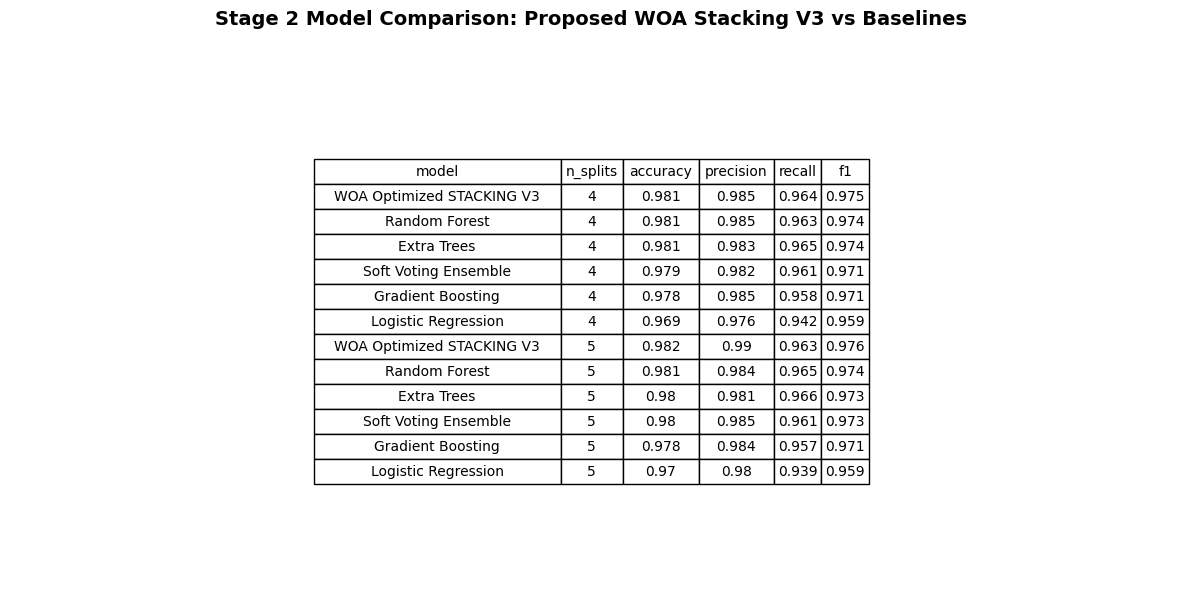

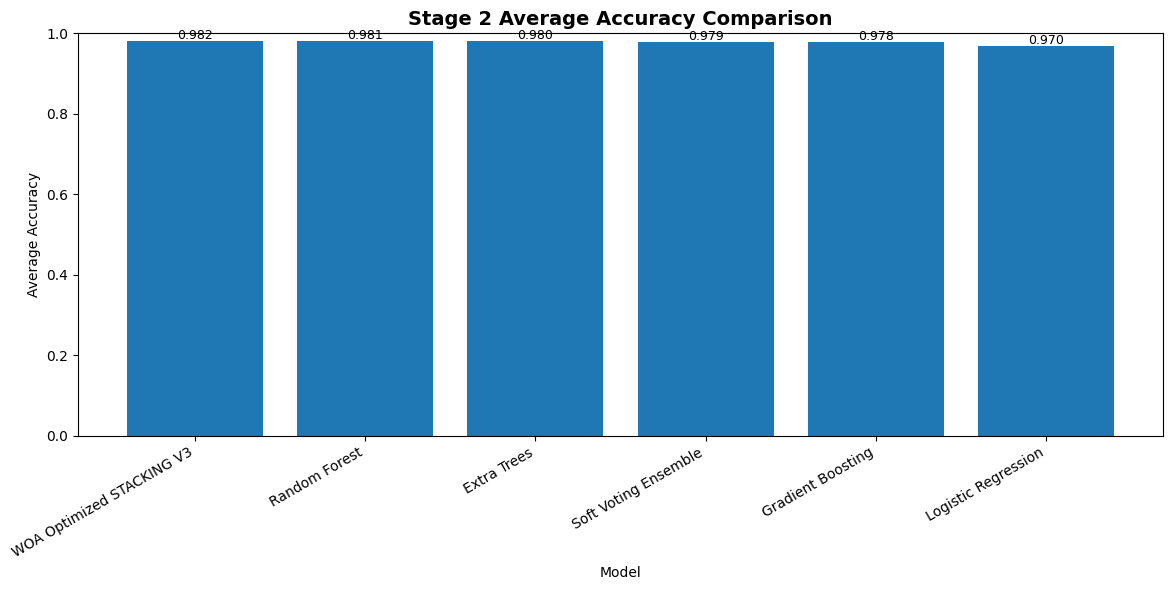

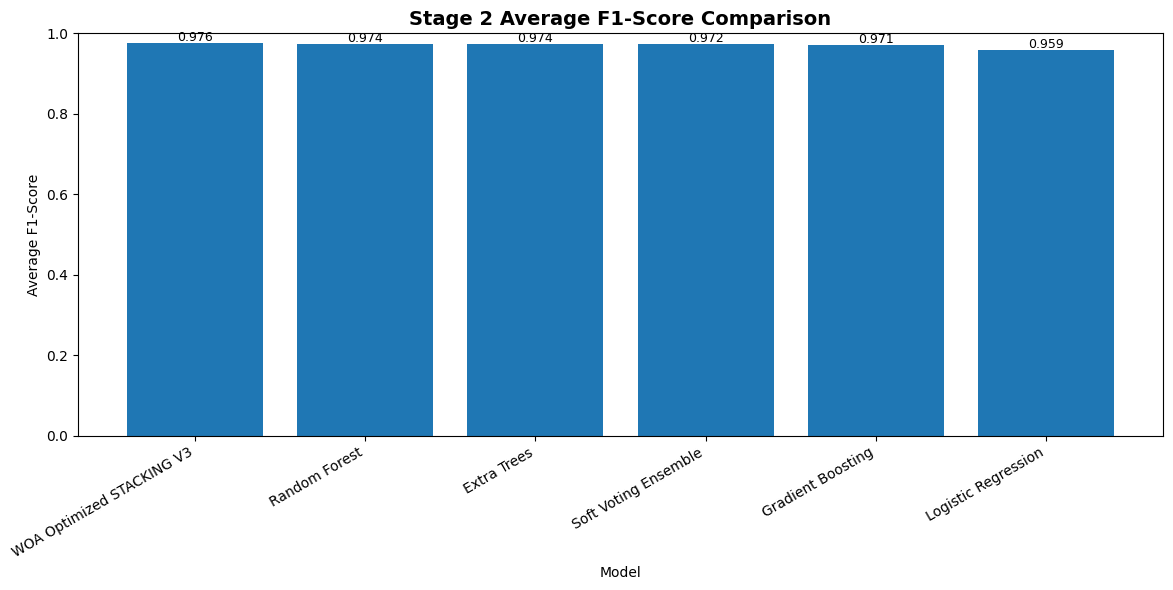


Best model by average Accuracy: WOA Optimized STACKING V3
Final production model selected: WOA Optimized STACKING V3

================ FINAL TRAINING ON FULL DATASET ================
Train core: (13531, 13)
Validation: (3383, 13)
Holdout   : (4229, 13)

Final selected model: WOA Optimized STACKING V3
Final threshold: 0.5000000000000002
Validation F1: 0.9794303797468354

================ FINAL HOLDOUT RESULTS ================
Accuracy : 0.9836840860723576
Precision: 0.9891581632653061
Recall   : 0.96756082345602
F1       : 0.978240302743614
ROC AUC  : 0.9976816602913711
PR AUC   : 0.9970215418828617

Confusion Matrix:
[[2609   17]
 [  52 1551]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2626
           1       0.99      0.97      0.98      1603

    accuracy                           0.98      4229
   macro avg       0.98      0.98      0.98      4229
weighted avg       0.98      0.98      0.98      42

In [1]:
# =============================================================================
# STAGE 2 — FINAL TRAINING PIPELINE ON CLEAN DATASET
# Text ↔ Text Matching
# Proposed Model: WOA Optimized STACKING V3
# Objective: Accuracy + F1 + Precision
# =============================================================================

import os
import re
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier
)

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

from sentence_transformers import SentenceTransformer


# =============================================================================
# CONFIG
# =============================================================================

DATA_PATH = "dataset_clean_ready.csv"
OUTPUT_DIR = "stage2_final_training"

os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
FOLD_OPTIONS = [4, 5]

POS_PER_SAMPLE = 2
NEG_HARD_PER_SAMPLE = 3
NEG_EASY_PER_SAMPLE = 1

# =============================================================================
# SEMANTIC PAIR GENERATION CONFIG — DATASET V2
# =============================================================================

# Positive pairs must be semantically close.
POSITIVE_MIN_SIM = 0.62

# Hard negatives are confusing negatives:
# same category, different subcategory, high semantic similarity.
HARD_NEGATIVE_MIN_SIM = 0.45

# Easy negatives:
# different category, preferably not too similar.
EASY_NEGATIVE_MAX_SIM = 0.55

# Candidate pool size to avoid selecting from all samples every time
TOP_K_POSITIVE_CANDIDATES = 30
TOP_K_HARD_NEGATIVE_CANDIDATES = 40
TOP_K_EASY_NEGATIVE_CANDIDATES = 40

EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

# =============================================================================
# Whale Optimization Algorithm config — V3
# =============================================================================

WOA_N_WHALES = 45
WOA_MAX_ITER = 80
WOA_RESTARTS = 5

WOA_THRESHOLD_MIN = 0.25
WOA_THRESHOLD_MAX = 0.85

# =============================================================================
# V3 OBJECTIVE CONFIG
# =============================================================================

WOA_ACC_WEIGHT = 0.78
WOA_PRECISION_WEIGHT = 0.12
WOA_F1_WEIGHT = 0.10

V3_MIN_RECALL = 0.84
V3_MIN_F1 = 0.86

V3_RECALL_PENALTY = 0.25
V3_F1_PENALTY = 0.20


# =============================================================================
# LOAD DATA
# =============================================================================

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df = df.reset_index(drop=True)

print("===== DATA LOADED =====")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

if "final_text" not in df.columns:
    if "clean_description" in df.columns:
        df["final_text"] = df["clean_description"]
    elif "dataset_description" in df.columns:
        df["final_text"] = df["dataset_description"]
    else:
        raise ValueError(
            "No valid text column found. Expected final_text or clean_description or dataset_description."
        )

required_cols = ["final_text", "category", "subcategory", "keywords"]

for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

df["final_text"] = df["final_text"].astype(str)
df["category"] = df["category"].astype(str)
df["subcategory"] = df["subcategory"].astype(str)
df["keywords"] = df["keywords"].astype(str)

df = df.drop_duplicates(subset=["final_text", "subcategory"]).reset_index(drop=True)
df["sample_id"] = df.index

print("\nAfter duplicate removal:", df.shape)
print("\nCategory distribution:")
print(df["category"].value_counts())

print("\nSubcategory distribution:")
print(df["subcategory"].value_counts())


# =============================================================================
# TEXT HELPERS
# =============================================================================

arabic_stopwords = set([
    "في", "من", "على", "مع", "هناك", "حيث", "هذه", "هذا",
    "تظهر", "يظهر", "صورة", "الصورة", "العناصر", "الظاهرة",
    "داخل", "إلى", "أن", "بما", "كما", "عن", "و", "أو",
    "هو", "هي", "كان", "كانت", "تم", "قد", "كل", "أي"
])


def normalize_text(text):
    text = str(text)
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text):
    text = normalize_text(text)
    words = text.split()
    words = [w for w in words if w not in arabic_stopwords and len(w) > 1]
    return words


def keyword_set(k):
    words = str(k).split("|")
    words = [normalize_text(w) for w in words]
    words = [w for w in words if len(w) > 1]
    return set(words)


def jaccard(s1, s2):
    if not s1 or not s2:
        return 0.0
    return len(s1 & s2) / len(s1 | s2)


def containment(s1, s2):
    if not s1 or not s2:
        return 0.0
    return len(s1 & s2) / min(len(s1), len(s2))


def length_features(t1, t2):
    len1 = len(str(t1))
    len2 = len(str(t2))

    diff = abs(len1 - len2)
    ratio = min(len1, len2) / max(len1, len2) if max(len1, len2) > 0 else 0

    return diff, ratio


def damage_terms_overlap(t1, t2):
    important_terms = [
        "تسريب", "تسرب", "مياه", "ميه", "ماء",
        "حنفية", "صنبور", "حوض", "صرف", "مجاري",
        "مرحاض", "تواليت", "انسداد", "مسدود", "ماسورة",
        "كهرباء", "نور", "إضاءة", "لمبة", "أسلاك", "سلك",
        "شرار", "ماس", "فيشة", "مقبس",
        "جدار", "حيطة", "حائط", "تشققات", "شروخ", "دهان",
        "طلاء", "سقف", "رطوبة", "بلل", "بقع",
        "باب", "شباك", "نافذة", "خشب", "درج", "سلم",
        "عطل", "تلف", "مشكلة", "خلل", "كسر"
    ]

    s1 = set([term for term in important_terms if term in str(t1)])
    s2 = set([term for term in important_terms if term in str(t2)])

    return jaccard(s1, s2)

# =============================================================================
# LOAD EMBEDDING MODEL
# =============================================================================

print("\n===== LOADING EMBEDDING MODEL =====")
embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)

# =============================================================================
# BUILD PAIRS — SEMANTIC FILTERING + HARD NEGATIVE MINING
# Dataset V2
# =============================================================================

print("\n===== SEMANTIC PAIR GENERATION STARTED =====")

# ---------------------------------------------------------
# Encode all dataset texts once
# ---------------------------------------------------------
df_texts = df["final_text"].tolist()

df_embeddings = embedder.encode(
    df_texts,
    normalize_embeddings=True,
    show_progress_bar=True
)

df_embeddings = np.asarray(df_embeddings)

print("Dataset embeddings shape:", df_embeddings.shape)


def semantic_similarity_by_index(i, candidate_indices):
    """
    Compute cosine similarity between sample i and candidate samples.
    Because embeddings are normalized, dot product = cosine similarity.
    """
    if len(candidate_indices) == 0:
        return np.array([])

    candidate_embs = df_embeddings[candidate_indices]
    sims = candidate_embs @ df_embeddings[i]

    return sims


def select_top_candidates(i, candidate_indices, top_k=None, min_sim=None, max_sim=None, highest=True):
    """
    Select semantic candidates based on similarity.
    highest=True  -> choose most similar candidates
    highest=False -> choose least similar candidates
    """

    candidate_indices = list(candidate_indices)

    if len(candidate_indices) == 0:
        return []

    sims = semantic_similarity_by_index(i, candidate_indices)

    temp = pd.DataFrame({
        "idx": candidate_indices,
        "sim": sims
    })

    if min_sim is not None:
        temp = temp[temp["sim"] >= min_sim]

    if max_sim is not None:
        temp = temp[temp["sim"] <= max_sim]

    if len(temp) == 0:
        return []

    temp = temp.sort_values("sim", ascending=not highest)

    if top_k is not None:
        temp = temp.head(top_k)

    return list(zip(temp["idx"].tolist(), temp["sim"].tolist()))


pairs = []

positive_count = 0
hard_negative_count = 0
easy_negative_count = 0

fallback_positive_count = 0
fallback_hard_negative_count = 0
fallback_easy_negative_count = 0


for idx, row in df.iterrows():

    text1 = row["final_text"]

    # =============================================================================
    # POSITIVE PAIRS
    # same subcategory + high semantic similarity
    # =============================================================================

    pos_pool_indices = df[
        (df["subcategory"] == row["subcategory"]) &
        (df.index != idx)
    ].index.tolist()

    selected_positive_candidates = select_top_candidates(
        i=idx,
        candidate_indices=pos_pool_indices,
        top_k=TOP_K_POSITIVE_CANDIDATES,
        min_sim=POSITIVE_MIN_SIM,
        max_sim=None,
        highest=True
    )

    # لو مفيش positives كفاية بسبب threshold، ناخد أعلى candidates بدون threshold كـ fallback
    if len(selected_positive_candidates) < POS_PER_SAMPLE:
        fallback_candidates = select_top_candidates(
            i=idx,
            candidate_indices=pos_pool_indices,
            top_k=TOP_K_POSITIVE_CANDIDATES,
            min_sim=None,
            max_sim=None,
            highest=True
        )

        existing_ids = set([x[0] for x in selected_positive_candidates])

        for cand_idx, sim in fallback_candidates:
            if cand_idx not in existing_ids:
                selected_positive_candidates.append((cand_idx, sim))
                fallback_positive_count += 1

            if len(selected_positive_candidates) >= POS_PER_SAMPLE:
                break

    selected_positive_candidates = selected_positive_candidates[:POS_PER_SAMPLE]

    for pos_idx, sim in selected_positive_candidates:
        pos = df.loc[pos_idx]

        pairs.append({
            "id1": row["sample_id"],
            "id2": pos["sample_id"],
            "text1": text1,
            "text2": pos["final_text"],
            "cat1": row["category"],
            "cat2": pos["category"],
            "sub1": row["subcategory"],
            "sub2": pos["subcategory"],
            "kw1": row["keywords"],
            "kw2": pos["keywords"],
            "semantic_pair_sim": sim,
            "label": 1,
            "pair_type": "semantic_positive"
        })

        positive_count += 1

    # =============================================================================
    # HARD NEGATIVE PAIRS
    # same category + different subcategory + high semantic similarity
    # =============================================================================

    hard_pool_indices = df[
        (df["category"] == row["category"]) &
        (df["subcategory"] != row["subcategory"])
    ].index.tolist()

    selected_hard_candidates = select_top_candidates(
        i=idx,
        candidate_indices=hard_pool_indices,
        top_k=TOP_K_HARD_NEGATIVE_CANDIDATES,
        min_sim=HARD_NEGATIVE_MIN_SIM,
        max_sim=None,
        highest=True
    )

    # fallback لو مفيش hard negatives كفاية
    if len(selected_hard_candidates) < NEG_HARD_PER_SAMPLE:
        fallback_candidates = select_top_candidates(
            i=idx,
            candidate_indices=hard_pool_indices,
            top_k=TOP_K_HARD_NEGATIVE_CANDIDATES,
            min_sim=None,
            max_sim=None,
            highest=True
        )

        existing_ids = set([x[0] for x in selected_hard_candidates])

        for cand_idx, sim in fallback_candidates:
            if cand_idx not in existing_ids:
                selected_hard_candidates.append((cand_idx, sim))
                fallback_hard_negative_count += 1

            if len(selected_hard_candidates) >= NEG_HARD_PER_SAMPLE:
                break

    selected_hard_candidates = selected_hard_candidates[:NEG_HARD_PER_SAMPLE]

    for neg_idx, sim in selected_hard_candidates:
        neg = df.loc[neg_idx]

        pairs.append({
            "id1": row["sample_id"],
            "id2": neg["sample_id"],
            "text1": text1,
            "text2": neg["final_text"],
            "cat1": row["category"],
            "cat2": neg["category"],
            "sub1": row["subcategory"],
            "sub2": neg["subcategory"],
            "kw1": row["keywords"],
            "kw2": neg["keywords"],
            "semantic_pair_sim": sim,
            "label": 0,
            "pair_type": "semantic_hard_negative"
        })

        hard_negative_count += 1

    # =============================================================================
    # EASY NEGATIVE PAIRS
    # different category + preferably low/medium semantic similarity
    # =============================================================================

    easy_pool_indices = df[
        df["category"] != row["category"]
    ].index.tolist()

    selected_easy_candidates = select_top_candidates(
        i=idx,
        candidate_indices=easy_pool_indices,
        top_k=TOP_K_EASY_NEGATIVE_CANDIDATES,
        min_sim=None,
        max_sim=EASY_NEGATIVE_MAX_SIM,
        highest=False
    )

    # fallback لو مفيش easy negatives كفاية
    if len(selected_easy_candidates) < NEG_EASY_PER_SAMPLE:
        fallback_candidates = select_top_candidates(
            i=idx,
            candidate_indices=easy_pool_indices,
            top_k=TOP_K_EASY_NEGATIVE_CANDIDATES,
            min_sim=None,
            max_sim=None,
            highest=False
        )

        existing_ids = set([x[0] for x in selected_easy_candidates])

        for cand_idx, sim in fallback_candidates:
            if cand_idx not in existing_ids:
                selected_easy_candidates.append((cand_idx, sim))
                fallback_easy_negative_count += 1

            if len(selected_easy_candidates) >= NEG_EASY_PER_SAMPLE:
                break

    selected_easy_candidates = selected_easy_candidates[:NEG_EASY_PER_SAMPLE]

    for neg_idx, sim in selected_easy_candidates:
        neg = df.loc[neg_idx]

        pairs.append({
            "id1": row["sample_id"],
            "id2": neg["sample_id"],
            "text1": text1,
            "text2": neg["final_text"],
            "cat1": row["category"],
            "cat2": neg["category"],
            "sub1": row["subcategory"],
            "sub2": neg["subcategory"],
            "kw1": row["keywords"],
            "kw2": neg["keywords"],
            "semantic_pair_sim": sim,
            "label": 0,
            "pair_type": "semantic_easy_negative"
        })

        easy_negative_count += 1


pairs_df = pd.DataFrame(pairs)

pairs_df = pairs_df.drop_duplicates(
    subset=["id1", "id2", "label"]
).reset_index(drop=True)

pairs_df = pairs_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("\n===== PAIRS DATASET V2 =====")
print("Pairs shape:", pairs_df.shape)

print("\nLabel distribution:")
print(pairs_df["label"].value_counts())

print("\nPair type distribution:")
print(pairs_df["pair_type"].value_counts())

print("\nSemantic similarity by pair type:")
print(
    pairs_df
    .groupby("pair_type")["semantic_pair_sim"]
    .agg(["count", "mean", "min", "max"])
    .round(4)
)

print("\n===== FALLBACK SUMMARY =====")
print("Fallback positive pairs:", fallback_positive_count)
print("Fallback hard negative pairs:", fallback_hard_negative_count)
print("Fallback easy negative pairs:", fallback_easy_negative_count)

pairs_df.to_csv(
    os.path.join(OUTPUT_DIR, "stage2_pairs_dataset_v2_semantic.csv"),
    index=False,
    encoding="utf-8-sig"
)

# =============================================================================
# USER-STYLE QUERY AUGMENTATION
# Adds realistic customer-style descriptions to improve real-world generalization
# =============================================================================

print("\n===== USER-STYLE QUERY AUGMENTATION STARTED =====")

user_style_templates = {
    "تسريب مياه": [
        "الحنفية بتسرب ميه طول الوقت",
        "في ميه بتنزل من الصنبور حتى وهو مقفول",
        "في تسريب مياه تحت الحوض",
        "الميه بتنقط من المواسير",
        "في بلل واضح جنب مصدر المياه"
    ],

    "عطل صرف": [
        "الحوض مسدود والمياه مش بتنزل",
        "الصرف واقف ومفيش ميه بتنزل",
        "الميه بتتجمع في الحوض",
        "صرف الحمام مسدود",
        "في انسداد في البلاعة"
    ],

    "عطل مرحاض": [
        "المرحاض مسدود ومش بيسحب المياه",
        "السيفون مش شغال كويس",
        "التواليت فيه انسداد",
        "في مشكلة في قاعدة الحمام",
        "الميه مش بتنزل من المرحاض"
    ],

    "عطل كهرباء عام": [
        "النور بيقطع ويرجع لوحده",
        "فيشة الكهرباء بتطلع شرار",
        "الكهرباء فاصلة في الأوضة",
        "المقبس مش شغال",
        "الإضاءة بتفصل بشكل متكرر"
    ],

    "تشققات جدار": [
        "في شروخ واضحة في الحيطة",
        "الجدار فيه تشققات",
        "في شرخ طويل في الحائط",
        "الحيطة مشققة ومحتاجة تصليح",
        "في تشققات ظاهرة على الجدار"
    ],

    "تلف دهان": [
        "الدهان مقشر على الحائط",
        "الطلاء واقع من الجدار",
        "في بقع رطوبة على الدهان",
        "الدهان بايظ ومحتاج يتجدد",
        "الحائط فيه تقشير في الطلاء"
    ],

    "تلف سقف": [
        "السقف فيه رطوبة",
        "في دهان واقع من السقف",
        "السقف فيه آثار مياه",
        "في بقع رطوبة في السقف",
        "السقف محتاج تصليح بسبب البلل"
    ],

    "عطل باب": [
        "الباب مش بيقفل كويس",
        "الباب الخشب بيحك في الأرض",
        "مفصلة الباب بايظة",
        "الباب مخلوع من المفصلة",
        "الباب محتاج نجار عشان مش بيتقفل"
    ],

    "عطل خشب": [
        "الشباك الخشب مكسور",
        "الدرفة بتاعة المطبخ مفكوكة",
        "في جزء خشب مكسور",
        "الخشب متآكل ومحتاج تصليح",
        "إطار الشباك الخشب بايظ"
    ],

    "عطل نجارة عام": [
        "في مشكلة نجارة في البيت",
        "محتاج نجار يصلح حاجة خشب",
        "في عطل في الخشب",
        "في جزء خشبي مفكوك",
        "محتاج تصليح نجارة"
    ],

    "عطل سباكة عام": [
        "في مشكلة سباكة في الحمام",
        "محتاج سباك يصلح العطل",
        "في عطل في المياه",
        "في مشكلة في مواسير المياه",
        "السباكة محتاجة تصليح"
    ],

    "عطل نقاشة عام": [
        "محتاج نقاش يصلح الحائط",
        "في مشكلة في الدهان",
        "الحائط محتاج تشطيب",
        "في عيب في النقاشة",
        "الدهان محتاج صيانة"
    ]
}


# =============================================================================
# Helper: find nearest real dataset samples for each subcategory
# =============================================================================

def get_reference_rows_by_subcategory(subcategory, max_refs=8):
    subset = df[df["subcategory"] == subcategory].copy()

    if len(subset) == 0:
        return pd.DataFrame()

    return subset.sample(
        n=min(max_refs, len(subset)),
        random_state=RANDOM_STATE
    ).reset_index(drop=True)


augmented_pairs = []

aug_id_start = int(df["sample_id"].max()) + 100000


for subcategory, user_queries in user_style_templates.items():

    reference_rows = get_reference_rows_by_subcategory(
        subcategory=subcategory,
        max_refs=8
    )

    if len(reference_rows) == 0:
        print(f"⚠️ No reference rows found for subcategory: {subcategory}")
        continue

    # category of this subcategory
    category = reference_rows.iloc[0]["category"]

    for q_idx, user_query in enumerate(user_queries):

        # ---------------------------------------------------------
        # POSITIVE USER-STYLE PAIRS
        # user query ↔ real dataset text from same subcategory
        # ---------------------------------------------------------
        pos_refs = reference_rows.sample(
            n=min(2, len(reference_rows)),
            random_state=RANDOM_STATE + q_idx
        )

        for _, pos in pos_refs.iterrows():

            # semantic similarity for feature consistency
            q_emb = embedder.encode(user_query, normalize_embeddings=True)
            pos_emb = embedder.encode(pos["final_text"], normalize_embeddings=True)
            sim = float(np.sum(q_emb * pos_emb))

            augmented_pairs.append({
                "id1": aug_id_start,
                "id2": pos["sample_id"],
                "text1": user_query,
                "text2": pos["final_text"],
                "cat1": category,
                "cat2": pos["category"],
                "sub1": subcategory,
                "sub2": pos["subcategory"],
                "kw1": "|".join(tokenize(user_query)),
                "kw2": pos["keywords"],
                "semantic_pair_sim": sim,
                "label": 1,
                "pair_type": "user_style_positive"
            })

            aug_id_start += 1

        # ---------------------------------------------------------
        # HARD NEGATIVE USER-STYLE PAIRS
        # user query ↔ same category, different subcategory
        # ---------------------------------------------------------
        hard_neg_pool = df[
            (df["category"] == category) &
            (df["subcategory"] != subcategory)
        ].copy()

        if len(hard_neg_pool) > 0:
            hard_neg_refs = hard_neg_pool.sample(
                n=min(2, len(hard_neg_pool)),
                random_state=RANDOM_STATE + q_idx + 500
            )

            for _, neg in hard_neg_refs.iterrows():

                q_emb = embedder.encode(user_query, normalize_embeddings=True)
                neg_emb = embedder.encode(neg["final_text"], normalize_embeddings=True)
                sim = float(np.sum(q_emb * neg_emb))

                augmented_pairs.append({
                    "id1": aug_id_start,
                    "id2": neg["sample_id"],
                    "text1": user_query,
                    "text2": neg["final_text"],
                    "cat1": category,
                    "cat2": neg["category"],
                    "sub1": subcategory,
                    "sub2": neg["subcategory"],
                    "kw1": "|".join(tokenize(user_query)),
                    "kw2": neg["keywords"],
                    "semantic_pair_sim": sim,
                    "label": 0,
                    "pair_type": "user_style_hard_negative"
                })

                aug_id_start += 1

        # ---------------------------------------------------------
        # EASY NEGATIVE USER-STYLE PAIR
        # user query ↔ different category
        # ---------------------------------------------------------
        easy_neg_pool = df[df["category"] != category].copy()

        if len(easy_neg_pool) > 0:
            easy_neg_ref = easy_neg_pool.sample(
                n=1,
                random_state=RANDOM_STATE + q_idx + 1000
            ).iloc[0]

            q_emb = embedder.encode(user_query, normalize_embeddings=True)
            easy_emb = embedder.encode(easy_neg_ref["final_text"], normalize_embeddings=True)
            sim = float(np.sum(q_emb * easy_emb))

            augmented_pairs.append({
                "id1": aug_id_start,
                "id2": easy_neg_ref["sample_id"],
                "text1": user_query,
                "text2": easy_neg_ref["final_text"],
                "cat1": category,
                "cat2": easy_neg_ref["category"],
                "sub1": subcategory,
                "sub2": easy_neg_ref["subcategory"],
                "kw1": "|".join(tokenize(user_query)),
                "kw2": easy_neg_ref["keywords"],
                "semantic_pair_sim": sim,
                "label": 0,
                "pair_type": "user_style_easy_negative"
            })

            aug_id_start += 1


augmented_pairs_df = pd.DataFrame(augmented_pairs)

print("\n===== USER-STYLE AUGMENTED PAIRS =====")
print("Augmented pairs shape:", augmented_pairs_df.shape)

print("\nAugmented label distribution:")
print(augmented_pairs_df["label"].value_counts())

print("\nAugmented pair type distribution:")
print(augmented_pairs_df["pair_type"].value_counts())

print("\nAugmented semantic similarity by pair type:")
print(
    augmented_pairs_df
    .groupby("pair_type")["semantic_pair_sim"]
    .agg(["count", "mean", "min", "max"])
    .round(4)
)


# =============================================================================
# Merge original semantic pairs + user-style augmented pairs
# =============================================================================

pairs_df = pd.concat(
    [pairs_df, augmented_pairs_df],
    ignore_index=True
)

pairs_df = pairs_df.drop_duplicates(
    subset=["text1", "text2", "label"]
).reset_index(drop=True)

pairs_df = pairs_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("\n===== FINAL PAIRS DATASET AFTER USER-STYLE AUGMENTATION =====")
print("Pairs shape:", pairs_df.shape)

print("\nFinal label distribution:")
print(pairs_df["label"].value_counts())

print("\nFinal pair type distribution:")
print(pairs_df["pair_type"].value_counts())

pairs_df.to_csv(
    os.path.join(OUTPUT_DIR, "stage2_pairs_dataset_v3_user_style_augmented.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ User-style augmented pairs added successfully.")
print("✅ Saved:", os.path.join(OUTPUT_DIR, "stage2_pairs_dataset_v3_user_style_augmented.csv"))

# =============================================================================
# USER-TO-USER AUGMENTATION
# Adds user-style text ↔ user-style text pairs
# This is important for real user descriptions and adversarial manual testing
# =============================================================================

print("\n===== USER-TO-USER AUGMENTATION STARTED =====")

# Get category for each subcategory from the original dataset
subcategory_to_category = (
    df.groupby("subcategory")["category"]
    .first()
    .to_dict()
)

user_user_pairs = []

user_aug_id_start = int(df["sample_id"].max()) + 200000


def compute_text_similarity(t1, t2):
    emb1 = embedder.encode(t1, normalize_embeddings=True)
    emb2 = embedder.encode(t2, normalize_embeddings=True)
    return float(np.sum(emb1 * emb2))


# =============================================================================
# 1) USER-TO-USER POSITIVE PAIRS
# Same subcategory, different user-style phrasings
# =============================================================================

for subcategory, queries in user_style_templates.items():

    if subcategory not in subcategory_to_category:
        print(f"⚠️ Skipping unknown subcategory: {subcategory}")
        continue

    category = subcategory_to_category[subcategory]

    for i in range(len(queries)):
        for j in range(i + 1, len(queries)):

            q1 = queries[i]
            q2 = queries[j]

            sim = compute_text_similarity(q1, q2)

            user_user_pairs.append({
                "id1": user_aug_id_start,
                "id2": user_aug_id_start + 1,
                "text1": q1,
                "text2": q2,
                "cat1": category,
                "cat2": category,
                "sub1": subcategory,
                "sub2": subcategory,
                "kw1": "|".join(tokenize(q1)),
                "kw2": "|".join(tokenize(q2)),
                "semantic_pair_sim": sim,
                "label": 1,
                "pair_type": "user_user_positive"
            })

            user_aug_id_start += 2


# =============================================================================
# 2) USER-TO-USER HARD NEGATIVE PAIRS
# Same category, different subcategory
# =============================================================================

subcategory_items = list(user_style_templates.items())

for sub1, queries1 in subcategory_items:

    if sub1 not in subcategory_to_category:
        continue

    cat1 = subcategory_to_category[sub1]

    for sub2, queries2 in subcategory_items:

        if sub2 not in subcategory_to_category:
            continue

        cat2 = subcategory_to_category[sub2]

        # same category only, different subcategory
        if cat1 != cat2 or sub1 == sub2:
            continue

        # Take limited combinations to avoid too many pairs
        for q1 in queries1[:3]:
            for q2 in queries2[:3]:

                sim = compute_text_similarity(q1, q2)

                user_user_pairs.append({
                    "id1": user_aug_id_start,
                    "id2": user_aug_id_start + 1,
                    "text1": q1,
                    "text2": q2,
                    "cat1": cat1,
                    "cat2": cat2,
                    "sub1": sub1,
                    "sub2": sub2,
                    "kw1": "|".join(tokenize(q1)),
                    "kw2": "|".join(tokenize(q2)),
                    "semantic_pair_sim": sim,
                    "label": 0,
                    "pair_type": "user_user_hard_negative"
                })

                user_aug_id_start += 2


# =============================================================================
# 3) USER-TO-USER EASY NEGATIVE PAIRS
# Different categories
# =============================================================================

for sub1, queries1 in subcategory_items:

    if sub1 not in subcategory_to_category:
        continue

    cat1 = subcategory_to_category[sub1]

    for sub2, queries2 in subcategory_items:

        if sub2 not in subcategory_to_category:
            continue

        cat2 = subcategory_to_category[sub2]

        # different category only
        if cat1 == cat2:
            continue

        # keep limited examples
        q1 = queries1[0]
        q2 = queries2[0]

        sim = compute_text_similarity(q1, q2)

        user_user_pairs.append({
            "id1": user_aug_id_start,
            "id2": user_aug_id_start + 1,
            "text1": q1,
            "text2": q2,
            "cat1": cat1,
            "cat2": cat2,
            "sub1": sub1,
            "sub2": sub2,
            "kw1": "|".join(tokenize(q1)),
            "kw2": "|".join(tokenize(q2)),
            "semantic_pair_sim": sim,
            "label": 0,
            "pair_type": "user_user_easy_negative"
        })

        user_aug_id_start += 2


user_user_pairs_df = pd.DataFrame(user_user_pairs)

print("\n===== USER-TO-USER AUGMENTED PAIRS =====")
print("User-to-user pairs shape:", user_user_pairs_df.shape)

print("\nUser-to-user label distribution:")
print(user_user_pairs_df["label"].value_counts())

print("\nUser-to-user pair type distribution:")
print(user_user_pairs_df["pair_type"].value_counts())

print("\nUser-to-user semantic similarity by pair type:")
print(
    user_user_pairs_df
    .groupby("pair_type")["semantic_pair_sim"]
    .agg(["count", "mean", "min", "max"])
    .round(4)
)


# =============================================================================
# Merge with current pairs_df
# =============================================================================

pairs_df = pd.concat(
    [pairs_df, user_user_pairs_df],
    ignore_index=True
)

pairs_df = pairs_df.drop_duplicates(
    subset=["text1", "text2", "label"]
).reset_index(drop=True)

pairs_df = pairs_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("\n===== FINAL PAIRS DATASET AFTER USER-TO-USER AUGMENTATION =====")
print("Pairs shape:", pairs_df.shape)

print("\nFinal label distribution:")
print(pairs_df["label"].value_counts())

print("\nFinal pair type distribution:")
print(pairs_df["pair_type"].value_counts())

pairs_df.to_csv(
    os.path.join(OUTPUT_DIR, "stage2_pairs_dataset_v4_user_to_user_augmented.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ User-to-user augmented pairs added successfully.")
print("✅ Saved:", os.path.join(OUTPUT_DIR, "stage2_pairs_dataset_v4_user_to_user_augmented.csv"))

# =============================================================================
# PRECOMPUTE EMBEDDINGS FOR UNIQUE TEXTS
# =============================================================================

print("\n===== PRECOMPUTING EMBEDDINGS FOR FEATURE BUILDING =====")

all_unique_texts = pd.concat([
    pairs_df["text1"],
    pairs_df["text2"]
]).drop_duplicates().tolist()

all_embeddings = embedder.encode(
    all_unique_texts,
    normalize_embeddings=True,
    show_progress_bar=True
)

embedding_cache = {
    text: emb for text, emb in zip(all_unique_texts, all_embeddings)
}

print("Unique texts embedded:", len(embedding_cache))


# =============================================================================
# FEATURE BUILDING
# =============================================================================

def cosine_pair_sparse(v1, v2):
    return np.array([
        cosine_similarity(v1[i], v2[i])[0][0]
        for i in range(v1.shape[0])
    ])


def get_embedding(text):
    if text in embedding_cache:
        return embedding_cache[text]
    else:
        emb = embedder.encode(text, normalize_embeddings=True)
        embedding_cache[text] = emb
        return emb


def build_features(data_part, word_tfidf, char_tfidf):

    data_part = data_part.reset_index(drop=True)

    # -------------------------
    # TF-IDF word similarity
    # -------------------------
    w1 = word_tfidf.transform(data_part["text1"])
    w2 = word_tfidf.transform(data_part["text2"])
    word_tfidf_sim = cosine_pair_sparse(w1, w2)

    # -------------------------
    # TF-IDF char similarity
    # -------------------------
    c1 = char_tfidf.transform(data_part["text1"])
    c2 = char_tfidf.transform(data_part["text2"])
    char_tfidf_sim = cosine_pair_sparse(c1, c2)

    # -------------------------
    # MiniLM semantic similarity
    # -------------------------
    emb1 = np.vstack([get_embedding(t) for t in data_part["text1"]])
    emb2 = np.vstack([get_embedding(t) for t in data_part["text2"]])

    minilm_sim = np.sum(emb1 * emb2, axis=1)

    # -------------------------
    # Keyword overlap
    # -------------------------
    keyword_sim = np.array([
        jaccard(keyword_set(a), keyword_set(b))
        for a, b in zip(data_part["kw1"], data_part["kw2"])
    ])

    # -------------------------
    # Word overlap
    # -------------------------
    word_jaccard = np.array([
        jaccard(set(tokenize(a)), set(tokenize(b)))
        for a, b in zip(data_part["text1"], data_part["text2"])
    ])

    word_containment = np.array([
        containment(set(tokenize(a)), set(tokenize(b)))
        for a, b in zip(data_part["text1"], data_part["text2"])
    ])

    # -------------------------
    # Domain terms overlap
    # -------------------------
    domain_overlap = np.array([
        damage_terms_overlap(a, b)
        for a, b in zip(data_part["text1"], data_part["text2"])
    ])

    # -------------------------
    # Length features
    # -------------------------
    length_data = np.array([
        length_features(a, b)
        for a, b in zip(data_part["text1"], data_part["text2"])
    ])

    len_diff = length_data[:, 0] / 100.0
    len_ratio = length_data[:, 1]

    # -------------------------
    # Category match
    # -------------------------
    cat_match = (data_part["cat1"] == data_part["cat2"]).astype(float).values

    # -------------------------
    # Precomputed semantic pair similarity
    # -------------------------
    if "semantic_pair_sim" in data_part.columns:
        semantic_pair_sim = data_part["semantic_pair_sim"].astype(float).values
    else:
        semantic_pair_sim = minilm_sim

    # -------------------------
    # Numeric feature interactions
    # -------------------------
    semantic_lexical_gap = np.abs(minilm_sim - word_tfidf_sim)
    semantic_keyword_product = minilm_sim * keyword_sim
    lexical_domain_product = word_tfidf_sim * domain_overlap

    X = np.vstack([
        minilm_sim,
        word_tfidf_sim,
        char_tfidf_sim,
        keyword_sim,
        word_jaccard,
        word_containment,
        domain_overlap,
        len_diff,
        len_ratio,
        cat_match,
        semantic_pair_sim,
        semantic_lexical_gap,
        semantic_keyword_product,
        lexical_domain_product
    ]).T

    return X

feature_names = [
    "minilm_sim",
    "word_tfidf_sim",
    "char_tfidf_sim",
    "keyword_sim",
    "word_jaccard",
    "word_containment",
    "domain_overlap",
    "len_diff",
    "len_ratio",
    "cat_match",
    "semantic_pair_sim",
    "semantic_lexical_gap",
    "semantic_keyword_product",
    "lexical_domain_product"
]


# =============================================================================
# MODELS
# =============================================================================

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=600,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=350,
        learning_rate=0.04,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}


# =============================================================================
# STACKING BASE MODELS — V3
# =============================================================================

stack_lr_base = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

stack_rf_base = RandomForestClassifier(
    n_estimators=700,
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

stack_et_base = ExtraTreesClassifier(
    n_estimators=800,
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

stack_gb_base = GradientBoostingClassifier(
    n_estimators=450,
    learning_rate=0.035,
    max_depth=3,
    random_state=RANDOM_STATE
)

stack_hgb_base = HistGradientBoostingClassifier(
    max_iter=450,
    learning_rate=0.035,
    max_leaf_nodes=31,
    l2_regularization=0.05,
    random_state=RANDOM_STATE
)

stack_svm_base = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        C=3.0,
        kernel="rbf",
        gamma="scale",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

stacking_base_models = {
    "stack_lr": stack_lr_base,
    "stack_rf": stack_rf_base,
    "stack_et": stack_et_base,
    "stack_gb": stack_gb_base,
    "stack_hgb": stack_hgb_base,
    "stack_svm": stack_svm_base
}


# =============================================================================
# SOFT VOTING ENSEMBLE
# =============================================================================

ensemble_model = VotingClassifier(
    estimators=[
        ("lr", Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ])),
        ("rf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
        ("et", ExtraTreesClassifier(
            n_estimators=600,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ],
    voting="soft",
    weights=[1, 1, 2]
)

models["Soft Voting Ensemble"] = ensemble_model


# =============================================================================
# THRESHOLD TUNING
# =============================================================================

def find_best_threshold(y_true, probs):
    best_t = 0.5
    best_f1 = -1

    for t in np.arange(0.25, 0.76, 0.01):
        preds = (probs >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1


def find_best_threshold_by_accuracy_f1_precision(y_true, probs):
    best_t = 0.5
    best_score = -1
    best_metrics = {}

    for t in np.arange(0.25, 0.76, 0.01):
        preds = (probs >= t).astype(int)

        acc = accuracy_score(y_true, preds)
        f1 = f1_score(y_true, preds, zero_division=0)
        precision = precision_score(y_true, preds, zero_division=0)
        recall = recall_score(y_true, preds, zero_division=0)

        score = (
            WOA_ACC_WEIGHT * acc +
            WOA_F1_WEIGHT * f1 +
            WOA_PRECISION_WEIGHT * precision
        )

        if score > best_score:
            best_score = score
            best_t = t
            best_metrics = {
                "accuracy": acc,
                "f1": f1,
                "precision": precision,
                "recall": recall,
                "score": score
            }

    return best_t, best_score, best_metrics


def evaluate_predictions(model_name, y_true, probs, threshold):
    y_pred = (probs >= threshold).astype(int)

    result = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probs),
        "pr_auc": average_precision_score(y_true, probs)
    }

    return result, y_pred

# =============================================================================
# V3 OBJECTIVE SCORE
# =============================================================================

def calculate_v3_objective_score(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)

    acc = accuracy_score(y_true, preds)
    precision = precision_score(y_true, preds, zero_division=0)
    recall = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)

    score = (
        WOA_ACC_WEIGHT * acc +
        WOA_PRECISION_WEIGHT * precision +
        WOA_F1_WEIGHT * f1
    )

    # Soft penalty لو recall نزل زيادة
    if recall < V3_MIN_RECALL:
        score -= V3_RECALL_PENALTY * (V3_MIN_RECALL - recall)

    # Soft penalty لو F1 نزل زيادة
    if f1 < V3_MIN_F1:
        score -= V3_F1_PENALTY * (V3_MIN_F1 - f1)

    metrics = {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "score": score
    }

    return score, metrics

# =============================================================================
# WHALE OPTIMIZATION ALGORITHM
# =============================================================================

def whale_optimization_algorithm(
    objective_function,
    dim,
    bounds,
    n_whales=30,
    max_iter=50,
    random_state=42
):

    rng = np.random.default_rng(random_state)

    lower_bounds = np.array([b[0] for b in bounds], dtype=float)
    upper_bounds = np.array([b[1] for b in bounds], dtype=float)

    whales = rng.uniform(lower_bounds, upper_bounds, size=(n_whales, dim))

    fitness = np.array([objective_function(w) for w in whales])
    best_index = np.argmin(fitness)

    best_position = whales[best_index].copy()
    best_score = fitness[best_index]

    history = []

    for iteration in range(max_iter):

        a = 2 - iteration * (2 / max_iter)

        for i in range(n_whales):

            r1 = rng.random()
            r2 = rng.random()

            A = 2 * a * r1 - a
            C = 2 * r2

            p = rng.random()
            b = 1
            l = rng.uniform(-1, 1)

            if p < 0.5:
                if abs(A) < 1:
                    D = abs(C * best_position - whales[i])
                    new_position = best_position - A * D
                else:
                    random_index = rng.integers(0, n_whales)
                    random_whale = whales[random_index]
                    D = abs(C * random_whale - whales[i])
                    new_position = random_whale - A * D
            else:
                D = abs(best_position - whales[i])
                new_position = (
                    D * np.exp(b * l) * np.cos(2 * np.pi * l)
                    + best_position
                )

            new_position = np.clip(new_position, lower_bounds, upper_bounds)
            whales[i] = new_position

        fitness = np.array([objective_function(w) for w in whales])
        current_best_index = np.argmin(fitness)

        if fitness[current_best_index] < best_score:
            best_score = fitness[current_best_index]
            best_position = whales[current_best_index].copy()

        history.append(best_score)

    return best_position, best_score, history


def normalize_weights(weights):
    weights = np.array(weights, dtype=float)
    weights = np.clip(weights, 0.0, 1.0)

    if weights.sum() == 0:
        weights = np.ones_like(weights) / len(weights)
    else:
        weights = weights / weights.sum()

    return weights


# =============================================================================
# WOA OPTIMIZED STACKING V3
# Accuracy-first + Multi-restart WOA + Threshold Local Search
# =============================================================================

def train_stacking_v3(X_train, y_train, X_val, X_test, y_val=None):

    trained_stack_models = {}
    val_stack_probs = []
    test_stack_probs = []

    # -------------------------
    # Train diverse base models
    # -------------------------
    for name, model in stacking_base_models.items():

        stack_model = clone(model)
        stack_model.fit(X_train, y_train)

        trained_stack_models[name] = stack_model

        val_probs = stack_model.predict_proba(X_val)[:, 1]
        test_probs = stack_model.predict_proba(X_test)[:, 1]

        val_stack_probs.append(val_probs)
        test_stack_probs.append(test_probs)

    val_stack_probs = np.vstack(val_stack_probs).T
    test_stack_probs = np.vstack(test_stack_probs).T

    n_models = val_stack_probs.shape[1]

    if y_val is None:
        default_weights = np.ones(n_models) / n_models

        val_probs = np.dot(val_stack_probs, default_weights)
        test_probs = np.dot(test_stack_probs, default_weights)

        stacking_artifact = {
            "type": "WOA Optimized Weighted Stacking V3",
            "trained_stack_models": trained_stack_models,
            "stacking_model_names": list(stacking_base_models.keys()),
            "weights": default_weights,
            "threshold": None,
            "woa_history": None,
            "objective": "Accuracy-first objective"
        }

        return val_probs, test_probs, stacking_artifact

    # -------------------------
    # WOA position = weights + threshold
    # -------------------------
    dim = n_models + 1
    bounds = [(0.0, 1.0)] * n_models + [(WOA_THRESHOLD_MIN, WOA_THRESHOLD_MAX)]

    def objective_function(position):

        weights = normalize_weights(position[:n_models])
        threshold = position[-1]

        final_probs = np.dot(val_stack_probs, weights)

        objective_score, _ = calculate_v3_objective_score(
            y_true=y_val,
            probs=final_probs,
            threshold=threshold
        )

        # WOA minimizes
        return 1 - objective_score

    # -------------------------
    # Multi-restart WOA
    # -------------------------
    best_position_overall = None
    best_loss_overall = np.inf
    best_history_overall = None

    for restart in range(WOA_RESTARTS):

        current_random_state = RANDOM_STATE + (restart * 100)

        best_position, best_loss, woa_history = whale_optimization_algorithm(
            objective_function=objective_function,
            dim=dim,
            bounds=bounds,
            n_whales=WOA_N_WHALES,
            max_iter=WOA_MAX_ITER,
            random_state=current_random_state
        )

        if best_loss < best_loss_overall:
            best_loss_overall = best_loss
            best_position_overall = best_position.copy()
            best_history_overall = woa_history

    best_weights = normalize_weights(best_position_overall[:n_models])
    best_threshold = best_position_overall[-1]

    # -------------------------
    # Local threshold search after WOA
    # -------------------------
    # بعد ما WOA يختار weights، نعمل search دقيق على threshold
    # عشان نطلع أعلى validation accuracy score ممكن.

    val_probs = np.dot(val_stack_probs, best_weights)

    best_local_threshold = best_threshold
    best_local_score = -1
    best_local_metrics = None

    for t in np.arange(WOA_THRESHOLD_MIN, WOA_THRESHOLD_MAX + 0.001, 0.005):

        score, metrics = calculate_v3_objective_score(
            y_true=y_val,
            probs=val_probs,
            threshold=t
        )

        if score > best_local_score:
            best_local_score = score
            best_local_threshold = t
            best_local_metrics = metrics

    best_threshold = best_local_threshold

    test_probs = np.dot(test_stack_probs, best_weights)

    val_preds = (val_probs >= best_threshold).astype(int)

    validation_accuracy = accuracy_score(y_val, val_preds)
    validation_precision = precision_score(y_val, val_preds, zero_division=0)
    validation_recall = recall_score(y_val, val_preds, zero_division=0)
    validation_f1 = f1_score(y_val, val_preds, zero_division=0)

    validation_objective_score, _ = calculate_v3_objective_score(
        y_true=y_val,
        probs=val_probs,
        threshold=best_threshold
    )

    stacking_artifact = {
        "type": "WOA Optimized Weighted Stacking V3",
        "trained_stack_models": trained_stack_models,
        "stacking_model_names": list(stacking_base_models.keys()),
        "weights": best_weights,
        "threshold": best_threshold,
        "woa_history": best_history_overall,
        "objective": "0.78 Accuracy + 0.12 Precision + 0.10 F1 with Recall/F1 soft constraints",
        "validation_accuracy": validation_accuracy,
        "validation_precision": validation_precision,
        "validation_recall": validation_recall,
        "validation_f1": validation_f1,
        "validation_objective_score": validation_objective_score,
        "best_local_metrics": best_local_metrics
    }

    return val_probs, test_probs, stacking_artifact


# =============================================================================
# K-FOLD TRAINING
# =============================================================================

best_global_f1 = -1
best_global_model = None
best_global_fold = None

groups = pairs_df["id1"].values
labels = pairs_df["label"].values

all_results = []

for N_SPLITS in FOLD_OPTIONS:

    print(f"\n\n🔥🔥 RUNNING {N_SPLITS}-FOLD 🔥🔥")

    sgkf = StratifiedGroupKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    for fold, (train_idx, test_idx) in enumerate(sgkf.split(pairs_df, labels, groups)):

        print(f"\n================ FOLD {fold + 1}/{N_SPLITS} ================")

        fold_train_df = pairs_df.iloc[train_idx].reset_index(drop=True)
        fold_test_df = pairs_df.iloc[test_idx].reset_index(drop=True)

        train_part_df, val_part_df = train_test_split(
            fold_train_df,
            test_size=0.2,
            stratify=fold_train_df["label"],
            random_state=RANDOM_STATE + fold
        )

        # ==========================
        # TF-IDF
        # ==========================
        word_tfidf = TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=30000,
            min_df=2,
            max_df=0.9,
            stop_words=list(arabic_stopwords)
        )

        char_tfidf = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            max_features=30000,
            min_df=2,
            max_df=0.95
        )

        train_texts = pd.concat([train_part_df["text1"], train_part_df["text2"]])
        word_tfidf.fit(train_texts)
        char_tfidf.fit(train_texts)

        # ==========================
        # FEATURES
        # ==========================
        X_train = build_features(train_part_df, word_tfidf, char_tfidf)
        y_train = train_part_df["label"].values

        X_val = build_features(val_part_df, word_tfidf, char_tfidf)
        y_val = val_part_df["label"].values

        X_test = build_features(fold_test_df, word_tfidf, char_tfidf)
        y_test = fold_test_df["label"].values

        # ==========================
        # NORMAL MODELS
        # ==========================
        for name, model in models.items():

            model.fit(X_train, y_train)

            val_probs = model.predict_proba(X_val)[:, 1]

            # Normal models still tuned by F1, عشان comparison عادل مع القديم
            best_t, _ = find_best_threshold(y_val, val_probs)

            test_probs = model.predict_proba(X_test)[:, 1]

            result, _ = evaluate_predictions(
                model_name=name,
                y_true=y_test,
                probs=test_probs,
                threshold=best_t
            )

            result["fold"] = fold + 1
            result["model"] = name
            result["n_splits"] = N_SPLITS

            all_results.append(result)

            if result["f1"] > best_global_f1:
                best_global_f1 = result["f1"]
                best_global_model = name
                best_global_fold = N_SPLITS

        # ==========================
        # PROPOSED STACKING V3
        # ==========================
        print("\n----- WOA OPTIMIZED STACKING V3 -----")
        
        val_probs, test_probs, stacking_artifact = train_stacking_v3(
            X_train,
            y_train,
            X_val,
            X_test,
            y_val=y_val
        )
        
        best_t = stacking_artifact["threshold"]
        
        result, _ = evaluate_predictions(
            model_name="WOA Optimized STACKING V3",
            y_true=y_test,
            probs=test_probs,
            threshold=best_t
        )
        
        result["fold"] = fold + 1
        result["model"] = "WOA Optimized STACKING V3"
        result["n_splits"] = N_SPLITS
        result["objective_score"] = stacking_artifact["validation_objective_score"]
        
        all_results.append(result)
        
        print("WOA V3 objective:", stacking_artifact["objective"])
        print("WOA V3 base models:", stacking_artifact["stacking_model_names"])
        print("WOA V3 weights:", stacking_artifact["weights"])
        print("WOA V3 threshold:", stacking_artifact["threshold"])
        print("WOA V3 validation accuracy:", stacking_artifact["validation_accuracy"])
        print("WOA V3 validation precision:", stacking_artifact["validation_precision"])
        print("WOA V3 validation recall:", stacking_artifact["validation_recall"])
        print("WOA V3 validation F1:", stacking_artifact["validation_f1"])
        print("WOA V3 validation objective score:", stacking_artifact["validation_objective_score"])
        
        if result["f1"] > best_global_f1:
            best_global_f1 = result["f1"]
            best_global_model = "WOA Optimized STACKING V3"
            best_global_fold = N_SPLITS


# =============================================================================
# FINAL CV SUMMARY
# =============================================================================

results_df = pd.DataFrame(all_results)

print("\n\n================ FINAL CV AVERAGE ================")

summary = (
    results_df
    .groupby("model")[[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
        "threshold"
    ]]
    .mean()
    .sort_values("accuracy", ascending=False)
)

print(summary)

results_df.to_csv(
    os.path.join(OUTPUT_DIR, "cv_detailed_results.csv"),
    index=False,
    encoding="utf-8-sig"
)

summary.to_csv(
    os.path.join(OUTPUT_DIR, "cv_summary_results.csv"),
    encoding="utf-8-sig"
)


# =============================================================================
# DETAILED MODEL COMPARISON TABLES
# =============================================================================

print("\n\n================ DETAILED MODEL COMPARISON ================")

detailed_table = (
    results_df
    .groupby(["model", "n_splits"])[
        [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "threshold"
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(["n_splits", "accuracy"], ascending=[True, False])
)

detailed_table_rounded = detailed_table.round(4)

print("\n===== DETAILED RESULTS TABLE (Model × Fold) =====")
print(detailed_table_rounded)

detailed_table_rounded.to_csv(
    os.path.join(OUTPUT_DIR, "model_comparison_by_folds.csv"),
    index=False,
    encoding="utf-8-sig"
)


pivot_table = results_df.pivot_table(
    index="model",
    columns="n_splits",
    values=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc"
    ],
    aggfunc="mean"
)

pivot_table = pivot_table.round(4)

print("\n===== PIVOT TABLE =====")
print(pivot_table)

pivot_table.to_csv(
    os.path.join(OUTPUT_DIR, "pivot_model_comparison.csv"),
    encoding="utf-8-sig"
)


best_per_fold = (
    detailed_table
    .sort_values(["n_splits", "accuracy"], ascending=[True, False])
    .groupby("n_splits")
    .head(1)
    .reset_index(drop=True)
)

best_per_fold = best_per_fold.round(4)

print("\n===== BEST MODEL PER FOLD SETTING BY ACCURACY =====")
print(best_per_fold)

best_per_fold.to_csv(
    os.path.join(OUTPUT_DIR, "best_model_per_fold_setting.csv"),
    index=False,
    encoding="utf-8-sig"
)


final_ranking = (
    results_df
    .groupby("model")[
        [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "threshold"
        ]
    ]
    .mean()
    .reset_index()
    .sort_values("accuracy", ascending=False)
)

final_ranking = final_ranking.round(4)

print("\n===== FINAL MODEL RANKING BY AVERAGE ACCURACY =====")
print(final_ranking)

final_ranking.to_csv(
    os.path.join(OUTPUT_DIR, "final_model_ranking.csv"),
    index=False,
    encoding="utf-8-sig"
)


# =============================================================================
# RF VS PROPOSED WOA STACKING V3 COMPARISON
# =============================================================================

rf_woa_comparison = results_df[
    results_df["model"].isin([
        "Random Forest",
        "WOA Optimized STACKING V3"
    ])
]

rf_woa_summary = (
    rf_woa_comparison
    .groupby("model")[
        [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "threshold"
        ]
    ]
    .mean()
    .reset_index()
    .sort_values("accuracy", ascending=False)
)

rf_woa_summary = rf_woa_summary.round(4)

print("\n===== RANDOM FOREST VS WOA OPTIMIZED STACKING V3 =====")
print(rf_woa_summary)

rf_woa_summary.to_csv(
    os.path.join(OUTPUT_DIR, "rf_vs_woa_stacking_v3_comparison.csv"),
    index=False,
    encoding="utf-8-sig"
)


# =============================================================================
# SAVE MODEL COMPARISON TABLE AS IMAGE
# =============================================================================

import matplotlib.pyplot as plt

presentation_table = (
    results_df
    .groupby(["model", "n_splits"])[
        [
            "accuracy",
            "precision",
            "recall",
            "f1"
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(["n_splits", "accuracy"], ascending=[True, False])
)

presentation_table = presentation_table.round(3)

print("\n===== PRESENTATION TABLE =====")
print(presentation_table)

fig, ax = plt.subplots(figsize=(15, 7))

ax.axis("off")

tbl = ax.table(
    cellText=presentation_table.values,
    colLabels=presentation_table.columns,
    loc="center",
    cellLoc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)
tbl.auto_set_column_width(col=list(range(len(presentation_table.columns))))

plt.title(
    "Stage 2 Model Comparison: Proposed WOA Stacking V3 vs Baselines",
    fontsize=14,
    weight="bold",
    pad=20
)

plt.savefig(
    os.path.join(OUTPUT_DIR, "model_comparison_table.png"),
    bbox_inches="tight",
    dpi=300
)

plt.show()


# =============================================================================
# BAR CHART — AVERAGE ACCURACY SCORE PER MODEL
# =============================================================================

accuracy_chart_data = (
    results_df
    .groupby("model")["accuracy"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    accuracy_chart_data.index,
    accuracy_chart_data.values
)

plt.title("Stage 2 Average Accuracy Comparison", fontsize=14, weight="bold")
plt.xlabel("Model")
plt.ylabel("Average Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)

for i, value in enumerate(accuracy_chart_data.values):
    plt.text(
        i,
        value + 0.005,
        f"{value:.3f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "average_accuracy_score_comparison.png"),
    bbox_inches="tight",
    dpi=300
)

plt.show()


# =============================================================================
# BAR CHART — AVERAGE F1 SCORE PER MODEL
# =============================================================================

f1_chart_data = (
    results_df
    .groupby("model")["f1"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    f1_chart_data.index,
    f1_chart_data.values
)

plt.title("Stage 2 Average F1-Score Comparison", fontsize=14, weight="bold")
plt.xlabel("Model")
plt.ylabel("Average F1-Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)

for i, value in enumerate(f1_chart_data.values):
    plt.text(
        i,
        value + 0.005,
        f"{value:.3f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "average_f1_score_comparison.png"),
    bbox_inches="tight",
    dpi=300
)

plt.show()


# =============================================================================
# FINAL MODEL DECISION
# =============================================================================

best_avg_model_name_by_accuracy = summary.index[0]

# في النسخة دي هنختار أفضل موديل حسب Accuracy
# لأن ده طلب الدكتور الحالي.
best_avg_model_name = best_avg_model_name_by_accuracy

print("\nBest model by average Accuracy:", best_avg_model_name_by_accuracy)
print("Final production model selected:", best_avg_model_name)


# =============================================================================
# FINAL TRAINING ON FULL DATASET
# =============================================================================

print("\n================ FINAL TRAINING ON FULL DATASET ================")

train_df_final, holdout_df = train_test_split(
    pairs_df,
    test_size=0.2,
    stratify=pairs_df["label"],
    random_state=RANDOM_STATE
)

train_df_final = train_df_final.reset_index(drop=True)
holdout_df = holdout_df.reset_index(drop=True)

train_core_df, val_df = train_test_split(
    train_df_final,
    test_size=0.2,
    stratify=train_df_final["label"],
    random_state=RANDOM_STATE
)

train_core_df = train_core_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train core:", train_core_df.shape)
print("Validation:", val_df.shape)
print("Holdout   :", holdout_df.shape)


final_word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30000,
    min_df=2,
    max_df=0.9,
    stop_words=list(arabic_stopwords)
)

final_char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=30000,
    min_df=2,
    max_df=0.95
)

final_train_texts = pd.concat([train_core_df["text1"], train_core_df["text2"]])

final_word_tfidf.fit(final_train_texts)
final_char_tfidf.fit(final_train_texts)

X_train_core = build_features(train_core_df, final_word_tfidf, final_char_tfidf)
y_train_core = train_core_df["label"].values

X_val_final = build_features(val_df, final_word_tfidf, final_char_tfidf)
y_val_final = val_df["label"].values

X_holdout = build_features(holdout_df, final_word_tfidf, final_char_tfidf)
y_holdout = holdout_df["label"].values


if best_avg_model_name == "WOA Optimized STACKING V3":

    val_probs, holdout_probs, final_stacking_artifact = train_stacking_v3(
        X_train_core,
        y_train_core,
        X_val_final,
        X_holdout,
        y_val=y_val_final
    )

    final_model = final_stacking_artifact
    final_threshold = final_stacking_artifact["threshold"]
    final_val_f1 = final_stacking_artifact["validation_f1"]

else:

    final_model = models[best_avg_model_name]

    final_model.fit(X_train_core, y_train_core)

    val_probs = final_model.predict_proba(X_val_final)[:, 1]

    final_threshold, final_val_score, final_val_metrics = find_best_threshold_by_accuracy_f1_precision(
        y_val_final,
        val_probs
    )

    final_val_f1 = final_val_metrics["f1"]


print("\nFinal selected model:", best_avg_model_name)
print("Final threshold:", final_threshold)
print("Validation F1:", final_val_f1)


# =============================================================================
# REFIT ON TRAIN_CORE + VALIDATION
# =============================================================================

full_final_train = pd.concat([train_core_df, val_df]).reset_index(drop=True)

final_word_tfidf_production = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30000,
    min_df=2,
    max_df=0.9,
    stop_words=list(arabic_stopwords)
)

final_char_tfidf_production = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=30000,
    min_df=2,
    max_df=0.95
)

full_final_texts = pd.concat([full_final_train["text1"], full_final_train["text2"]])

final_word_tfidf_production.fit(full_final_texts)
final_char_tfidf_production.fit(full_final_texts)

X_full_final_train = build_features(
    full_final_train,
    final_word_tfidf_production,
    final_char_tfidf_production
)

y_full_final_train = full_final_train["label"].values

X_holdout_final = build_features(
    holdout_df,
    final_word_tfidf_production,
    final_char_tfidf_production
)


if best_avg_model_name == "WOA Optimized STACKING V3":

    # هنا بنستخدم validation القديم عشان WOA يحدد weights و threshold
    val_probs_production, holdout_probs, final_model = train_stacking_v3(
        X_full_final_train,
        y_full_final_train,
        X_val_final,
        X_holdout_final,
        y_val=y_val_final
    )

    final_threshold = final_model["threshold"]

else:

    final_model.fit(X_full_final_train, y_full_final_train)
    holdout_probs = final_model.predict_proba(X_holdout_final)[:, 1]


holdout_pred = (holdout_probs >= final_threshold).astype(int)


print("\n================ FINAL HOLDOUT RESULTS ================")
print("Accuracy :", accuracy_score(y_holdout, holdout_pred))
print("Precision:", precision_score(y_holdout, holdout_pred, zero_division=0))
print("Recall   :", recall_score(y_holdout, holdout_pred, zero_division=0))
print("F1       :", f1_score(y_holdout, holdout_pred, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_holdout, holdout_probs))
print("PR AUC   :", average_precision_score(y_holdout, holdout_probs))

print("\nConfusion Matrix:")
print(confusion_matrix(y_holdout, holdout_pred))

print("\nClassification Report:")
print(classification_report(y_holdout, holdout_pred, zero_division=0))

production_binary_threshold = final_threshold

# =============================================================================
# TRI-STATE DECISION
# =============================================================================

def tri_state_decision(prob, accept_threshold, reject_threshold):
    if prob >= accept_threshold:
        return "MATCH"
    elif prob <= reject_threshold:
        return "MISMATCH"
    else:
        return "UNCERTAIN"



# =============================================================================
# IMPORTANT:
# Freeze the binary threshold used for final holdout evaluation
# before calculating tri-state thresholds.
# =============================================================================

production_binary_threshold = final_threshold

print("DEBUG production_binary_threshold before tri-state:", production_binary_threshold)

accept_threshold = min(production_binary_threshold + 0.08, 0.95)
reject_threshold = max(production_binary_threshold - 0.18, 0.05)

print("DEBUG accept_threshold:", accept_threshold)
print("DEBUG reject_threshold:", reject_threshold)

tri_preds = np.array([
    tri_state_decision(p, accept_threshold, reject_threshold)
    for p in holdout_probs
])

coverage = np.mean(tri_preds != "UNCERTAIN")

accepted_mask = tri_preds == "MATCH"
rejected_mask = tri_preds == "MISMATCH"

accept_precision = None
reject_precision = None

if accepted_mask.sum() > 0:
    accept_precision = np.mean(y_holdout[accepted_mask] == 1)

if rejected_mask.sum() > 0:
    reject_precision = np.mean(y_holdout[rejected_mask] == 0)


print("\n================ FINAL TRI-STATE RESULTS ================")
print("Binary threshold:", production_binary_threshold)
print("Accept threshold:", accept_threshold)
print("Reject threshold:", reject_threshold)
print("Accepted samples :", accepted_mask.sum())
print("Rejected samples :", rejected_mask.sum())
print("Uncertain samples:", np.sum(tri_preds == "UNCERTAIN"))
print("Coverage:", coverage)
print("Accept precision:", accept_precision)
print("Reject precision:", reject_precision)


# =============================================================================
# SAVE ARTIFACTS
# =============================================================================

joblib.dump(final_model, os.path.join(OUTPUT_DIR, "stage2_best_model.joblib"))
joblib.dump(final_word_tfidf_production, os.path.join(OUTPUT_DIR, "stage2_word_tfidf.joblib"))
joblib.dump(final_char_tfidf_production, os.path.join(OUTPUT_DIR, "stage2_char_tfidf.joblib"))
joblib.dump(feature_names, os.path.join(OUTPUT_DIR, "stage2_feature_names.joblib"))
joblib.dump(final_threshold, os.path.join(OUTPUT_DIR, "stage2_binary_threshold.joblib"))
joblib.dump(accept_threshold, os.path.join(OUTPUT_DIR, "stage2_accept_threshold.joblib"))
joblib.dump(reject_threshold, os.path.join(OUTPUT_DIR, "stage2_reject_threshold.joblib"))

df.to_csv(
    os.path.join(OUTPUT_DIR, "stage2_clean_reference_dataset.csv"),
    index=False,
    encoding="utf-8-sig"
)

pairs_df.to_csv(
    os.path.join(OUTPUT_DIR, "stage2_final_pairs.csv"),
    index=False,
    encoding="utf-8-sig"
)


# =============================================================================
# CHECK SAVED ARTIFACTS
# =============================================================================

required_files = [
    "stage2_best_model.joblib",
    "stage2_word_tfidf.joblib",
    "stage2_char_tfidf.joblib",
    "stage2_feature_names.joblib",
    "stage2_binary_threshold.joblib",
    "stage2_accept_threshold.joblib",
    "stage2_reject_threshold.joblib",
    "stage2_clean_reference_dataset.csv",
    "stage2_final_pairs.csv",
    "cv_detailed_results.csv",
    "cv_summary_results.csv",
    "model_comparison_by_folds.csv",
    "pivot_model_comparison.csv",
    "final_model_ranking.csv",
    "rf_vs_woa_stacking_v3_comparison.csv",
    "model_comparison_table.png",
    "average_accuracy_score_comparison.png",
    "average_f1_score_comparison.png"
]

print("\n================ CHECK SAVED FILES ================")

missing_files = []
existing_files = []

for file_name in required_files:
    file_path = os.path.join(OUTPUT_DIR, file_name)

    if os.path.exists(file_path):
        existing_files.append(file_name)
        size_kb = os.path.getsize(file_path) / 1024
        print(f"✅ FOUND   : {file_name} | Size: {size_kb:.2f} KB")
    else:
        missing_files.append(file_name)
        print(f"❌ MISSING : {file_name}")

print("\n================ SUMMARY ================")
print("Total required files:", len(required_files))
print("Found files:", len(existing_files))
print("Missing files:", len(missing_files))

if len(missing_files) == 0:
    print("\n✅ All required Stage 2 artifacts and reports were saved successfully.")
else:
    print("\n⚠️ Missing files:")
    for f in missing_files:
        print("-", f)


print("\n✅ Saved artifacts in:", OUTPUT_DIR)
print("✅ Stage 2 final training pipeline finished successfully.")
print("\n🏆 BEST GLOBAL MODEL:", best_global_model)
print("🏆 BEST FOLD:", best_global_fold)
print("🏆 BEST F1:", best_global_f1)
print("✅ FINAL PRODUCTION MODEL:", best_avg_model_name)

In [2]:
# =============================================================================
# STAGE 2 — PRODUCTION INFERENCE CELL
# Text ↔ Text Matching
# Uses saved Stage 2 artifacts:
# - WOA Optimized STACKING V3
# - TF-IDF vectorizers
# - Thresholds
# - Clean reference dataset
# =============================================================================

import os
import re
import joblib
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


# =============================================================================
# CONFIG
# =============================================================================

STAGE2_ARTIFACTS_DIR = "stage2_final_training"

EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

MODEL_PATH = os.path.join(STAGE2_ARTIFACTS_DIR, "stage2_best_model.joblib")
WORD_TFIDF_PATH = os.path.join(STAGE2_ARTIFACTS_DIR, "stage2_word_tfidf.joblib")
CHAR_TFIDF_PATH = os.path.join(STAGE2_ARTIFACTS_DIR, "stage2_char_tfidf.joblib")
FEATURE_NAMES_PATH = os.path.join(STAGE2_ARTIFACTS_DIR, "stage2_feature_names.joblib")
BINARY_THRESHOLD_PATH = os.path.join(STAGE2_ARTIFACTS_DIR, "stage2_binary_threshold.joblib")
ACCEPT_THRESHOLD_PATH = os.path.join(STAGE2_ARTIFACTS_DIR, "stage2_accept_threshold.joblib")
REJECT_THRESHOLD_PATH = os.path.join(STAGE2_ARTIFACTS_DIR, "stage2_reject_threshold.joblib")
REFERENCE_DATA_PATH = os.path.join(STAGE2_ARTIFACTS_DIR, "stage2_clean_reference_dataset.csv")


# =============================================================================
# LOAD ARTIFACTS
# =============================================================================

print("\n===== LOADING STAGE 2 ARTIFACTS =====")

stage2_model = joblib.load(MODEL_PATH)
word_tfidf = joblib.load(WORD_TFIDF_PATH)
char_tfidf = joblib.load(CHAR_TFIDF_PATH)
feature_names = joblib.load(FEATURE_NAMES_PATH)

binary_threshold = joblib.load(BINARY_THRESHOLD_PATH)
accept_threshold = joblib.load(ACCEPT_THRESHOLD_PATH)
reject_threshold = joblib.load(REJECT_THRESHOLD_PATH)

reference_df = pd.read_csv(REFERENCE_DATA_PATH, encoding="utf-8-sig")

reference_df["final_text"] = reference_df["final_text"].astype(str)
reference_df["category"] = reference_df["category"].astype(str)
reference_df["subcategory"] = reference_df["subcategory"].astype(str)
reference_df["keywords"] = reference_df["keywords"].astype(str)

print("Model loaded successfully.")
print("Reference dataset shape:", reference_df.shape)
print("Binary threshold:", binary_threshold)
print("Accept threshold:", accept_threshold)
print("Reject threshold:", reject_threshold)
print("Feature count:", len(feature_names))


# =============================================================================
# LOAD EMBEDDING MODEL
# =============================================================================

print("\n===== LOADING EMBEDDING MODEL =====")

embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)

embedding_cache = {}


def get_embedding(text):
    text = str(text)

    if text in embedding_cache:
        return embedding_cache[text]

    emb = embedder.encode(
        text,
        normalize_embeddings=True
    )

    embedding_cache[text] = emb
    return emb


# =============================================================================
# TEXT HELPERS
# =============================================================================

arabic_stopwords = set([
    "في", "من", "على", "مع", "هناك", "حيث", "هذه", "هذا",
    "تظهر", "يظهر", "صورة", "الصورة", "العناصر", "الظاهرة",
    "داخل", "إلى", "أن", "بما", "كما", "عن", "و", "أو",
    "هو", "هي", "كان", "كانت", "تم", "قد", "كل", "أي"
])


def normalize_text(text):
    text = str(text)
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text):
    text = normalize_text(text)
    words = text.split()
    words = [w for w in words if w not in arabic_stopwords and len(w) > 1]
    return words


def keyword_set(k):
    words = str(k).split("|")
    words = [normalize_text(w) for w in words]
    words = [w for w in words if len(w) > 1]
    return set(words)


def jaccard(s1, s2):
    if not s1 or not s2:
        return 0.0
    return len(s1 & s2) / len(s1 | s2)


def containment(s1, s2):
    if not s1 or not s2:
        return 0.0
    return len(s1 & s2) / min(len(s1), len(s2))


def length_features(t1, t2):
    len1 = len(str(t1))
    len2 = len(str(t2))

    diff = abs(len1 - len2)
    ratio = min(len1, len2) / max(len1, len2) if max(len1, len2) > 0 else 0

    return diff, ratio


def damage_terms_overlap(t1, t2):
    important_terms = [
        "تسريب", "تسرب", "مياه", "ميه", "ماء",
        "حنفية", "صنبور", "حوض", "صرف", "مجاري",
        "مرحاض", "تواليت", "انسداد", "مسدود", "ماسورة",
        "كهرباء", "نور", "إضاءة", "لمبة", "أسلاك", "سلك",
        "شرار", "ماس", "فيشة", "مقبس",
        "جدار", "حيطة", "حائط", "تشققات", "شروخ", "دهان",
        "طلاء", "سقف", "رطوبة", "بلل", "بقع",
        "باب", "شباك", "نافذة", "خشب", "درج", "سلم",
        "عطل", "تلف", "مشكلة", "خلل", "كسر"
    ]

    s1 = set([term for term in important_terms if term in str(t1)])
    s2 = set([term for term in important_terms if term in str(t2)])

    return jaccard(s1, s2)


# =============================================================================
# FEATURE EXTRACTION FOR ONE OR MANY PAIRS
# =============================================================================

def cosine_pair_sparse(v1, v2):
    return np.array([
        cosine_similarity(v1[i], v2[i])[0][0]
        for i in range(v1.shape[0])
    ])


def build_inference_features(pairs_part):
    pairs_part = pairs_part.reset_index(drop=True)

    # -------------------------
    # TF-IDF word similarity
    # -------------------------
    w1 = word_tfidf.transform(pairs_part["text1"])
    w2 = word_tfidf.transform(pairs_part["text2"])
    word_tfidf_sim = cosine_pair_sparse(w1, w2)

    # -------------------------
    # TF-IDF char similarity
    # -------------------------
    c1 = char_tfidf.transform(pairs_part["text1"])
    c2 = char_tfidf.transform(pairs_part["text2"])
    char_tfidf_sim = cosine_pair_sparse(c1, c2)

    # -------------------------
    # MiniLM semantic similarity
    # -------------------------
    emb1 = np.vstack([get_embedding(t) for t in pairs_part["text1"]])
    emb2 = np.vstack([get_embedding(t) for t in pairs_part["text2"]])

    minilm_sim = np.sum(emb1 * emb2, axis=1)

    # -------------------------
    # Keyword overlap
    # -------------------------
    keyword_sim = np.array([
        jaccard(keyword_set(a), keyword_set(b))
        for a, b in zip(pairs_part["kw1"], pairs_part["kw2"])
    ])

    # -------------------------
    # Word overlap
    # -------------------------
    word_jaccard = np.array([
        jaccard(set(tokenize(a)), set(tokenize(b)))
        for a, b in zip(pairs_part["text1"], pairs_part["text2"])
    ])

    word_containment = np.array([
        containment(set(tokenize(a)), set(tokenize(b)))
        for a, b in zip(pairs_part["text1"], pairs_part["text2"])
    ])

    # -------------------------
    # Domain terms overlap
    # -------------------------
    domain_overlap = np.array([
        damage_terms_overlap(a, b)
        for a, b in zip(pairs_part["text1"], pairs_part["text2"])
    ])

    # -------------------------
    # Length features
    # -------------------------
    length_data = np.array([
        length_features(a, b)
        for a, b in zip(pairs_part["text1"], pairs_part["text2"])
    ])

    len_diff = length_data[:, 0] / 100.0
    len_ratio = length_data[:, 1]

    # -------------------------
    # Category match
    # -------------------------
    cat_match = (pairs_part["cat1"] == pairs_part["cat2"]).astype(float).values

    # -------------------------
    # Precomputed semantic pair similarity
    # During inference, it equals MiniLM similarity.
    # -------------------------
    semantic_pair_sim = minilm_sim

    # -------------------------
    # Feature interactions
    # -------------------------
    semantic_lexical_gap = np.abs(minilm_sim - word_tfidf_sim)
    semantic_keyword_product = minilm_sim * keyword_sim
    lexical_domain_product = word_tfidf_sim * domain_overlap

    X = np.vstack([
        minilm_sim,
        word_tfidf_sim,
        char_tfidf_sim,
        keyword_sim,
        word_jaccard,
        word_containment,
        domain_overlap,
        len_diff,
        len_ratio,
        cat_match,
        semantic_pair_sim,
        semantic_lexical_gap,
        semantic_keyword_product,
        lexical_domain_product
    ]).T

    return X


# =============================================================================
# PREDICTION HELPERS
# =============================================================================

def predict_with_stage2_model(model, X):
    """
    Supports:
    1. Normal sklearn models
    2. WOA stacking artifact dictionary
    """

    if isinstance(model, dict) and "trained_stack_models" in model:

        model_names = model["stacking_model_names"]
        weights = np.array(model["weights"], dtype=float)

        stack_probs = []

        for model_name in model_names:
            base_model = model["trained_stack_models"][model_name]
            probs = base_model.predict_proba(X)[:, 1]
            stack_probs.append(probs)

        stack_probs = np.vstack(stack_probs).T
        final_probs = np.dot(stack_probs, weights)

        return final_probs

    else:
        return model.predict_proba(X)[:, 1]


def binary_decision(prob):
    if prob >= binary_threshold:
        return "MATCH"
    else:
        return "MISMATCH"


def tri_state_decision(prob):
    if prob >= accept_threshold:
        return "MATCH"
    elif prob <= reject_threshold:
        return "MISMATCH"
    else:
        return "UNCERTAIN"


# =============================================================================
# MAIN INFERENCE FUNCTION
# =============================================================================

def stage2_find_best_matches(
    user_description,
    top_k=5,
    restrict_category=None
):
    """
    Finds the best matching reference descriptions for a user complaint.

    Parameters:
    - user_description: Arabic user text
    - top_k: number of best matches to return
    - restrict_category: optional category filter مثل "سباكة" أو "كهرباء"

    Returns:
    - ranked DataFrame with match probabilities and decisions
    """

    user_description = str(user_description)

    if restrict_category is not None:
        candidates_df = reference_df[
            reference_df["category"] == restrict_category
        ].copy()
    else:
        candidates_df = reference_df.copy()

    if len(candidates_df) == 0:
        raise ValueError("No reference candidates found for the selected category.")

    inference_pairs = pd.DataFrame({
        "text1": [user_description] * len(candidates_df),
        "text2": candidates_df["final_text"].values,

        "cat1": candidates_df["category"].values,
        "cat2": candidates_df["category"].values,

        "sub1": candidates_df["subcategory"].values,
        "sub2": candidates_df["subcategory"].values,

        "kw1": ["|".join(tokenize(user_description))] * len(candidates_df),
        "kw2": candidates_df["keywords"].values
    })

    X_infer = build_inference_features(inference_pairs)

    probs = predict_with_stage2_model(stage2_model, X_infer)

    results = candidates_df.copy()
    results["match_probability"] = probs
    results["binary_decision"] = results["match_probability"].apply(binary_decision)
    results["tri_state_decision"] = results["match_probability"].apply(tri_state_decision)

    results = results.sort_values(
        "match_probability",
        ascending=False
    ).reset_index(drop=True)

    output_cols = [
        "match_probability",
        "binary_decision",
        "tri_state_decision",
        "category",
        "subcategory",
        "final_text",
        "keywords"
    ]

    return results[output_cols].head(top_k)


def stage2_single_pair_match(
    user_description,
    candidate_description,
    category,
    subcategory,
    candidate_keywords=""
):
    """
    Compares one user description against one candidate/reference description.
    Useful for Decision Engine later.
    """

    pair_df = pd.DataFrame([{
        "text1": str(user_description),
        "text2": str(candidate_description),

        "cat1": str(category),
        "cat2": str(category),

        "sub1": str(subcategory),
        "sub2": str(subcategory),

        "kw1": "|".join(tokenize(user_description)),
        "kw2": str(candidate_keywords)
    }])

    X_pair = build_inference_features(pair_df)
    prob = predict_with_stage2_model(stage2_model, X_pair)[0]

    return {
        "match_probability": float(prob),
        "binary_decision": binary_decision(prob),
        "tri_state_decision": tri_state_decision(prob),
        "binary_threshold": float(binary_threshold),
        "accept_threshold": float(accept_threshold),
        "reject_threshold": float(reject_threshold)
    }


print("\n✅ Stage 2 inference system is ready.")


===== LOADING STAGE 2 ARTIFACTS =====
Model loaded successfully.
Reference dataset shape: (3888, 8)
Binary threshold: 0.40000000000000013
Accept threshold: 0.48000000000000015
Reject threshold: 0.22000000000000014
Feature count: 14

===== LOADING EMBEDDING MODEL =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


✅ Stage 2 inference system is ready.


In [3]:
# =============================================================================
# STAGE 2 — CLEAN MANUAL SUBCATEGORY PROTOTYPES
# Production-friendly prototypes instead of noisy dataset descriptions
# =============================================================================

print("\n===== BUILDING MANUAL CLEAN SUBCATEGORY PROTOTYPES =====")

manual_prototypes = [
    {
        "category": "سباكة",
        "subcategory": "تسريب مياه",
        "prototype_text": "تسريب مياه حنفية صنبور ماسورة مواسير بلل تنقيط مياه تحت الحوض تسرب",
        "prototype_keywords": "تسريب|مياه|حنفية|صنبور|ماسورة|مواسير|بلل|تنقيط|تسرب"
    },
    {
        "category": "سباكة",
        "subcategory": "عطل صرف",
        "prototype_text": "انسداد صرف حوض بلاعة مياه لا تنزل المياه متجمعة الصرف مسدود",
        "prototype_keywords": "انسداد|صرف|حوض|بلاعة|مياه|مسدود|متجمعة"
    },
    {
        "category": "سباكة",
        "subcategory": "عطل مرحاض",
        "prototype_text": "عطل مرحاض تواليت قاعدة حمام سيفون انسداد المرحاض لا يسحب المياه",
        "prototype_keywords": "مرحاض|تواليت|قاعدة|حمام|سيفون|انسداد|مياه"
    },
    {
        "category": "سباكة",
        "subcategory": "عطل حوض",
        "prototype_text": "عطل حوض كسر حوض تسريب حوض انسداد حوض مياه حوض مشكلة في الحوض",
        "prototype_keywords": "حوض|كسر|تسريب|انسداد|مياه|مشكلة"
    },
    {
        "category": "سباكة",
        "subcategory": "عطل سباكة عام",
        "prototype_text": "مشكلة سباكة عامة عطل مياه مواسير حمام مطبخ سباك تصليح سباكة",
        "prototype_keywords": "سباكة|مياه|مواسير|حمام|مطبخ|سباك|تصليح"
    },
    {
        "category": "كهرباء",
        "subcategory": "عطل كهرباء عام",
        "prototype_text": "عطل كهرباء نور إضاءة فيشة مقبس سلك شرار ماس كهرباء الكهرباء فاصلة",
        "prototype_keywords": "كهرباء|نور|إضاءة|فيشة|مقبس|سلك|شرار|ماس"
    },
    {
        "category": "نقاشة",
        "subcategory": "تشققات جدار",
        "prototype_text": "تشققات جدار شروخ حائط حيطة شرخ في الجدار تشقق الحائط",
        "prototype_keywords": "تشققات|جدار|شروخ|حائط|حيطة|شرخ"
    },
    {
        "category": "نقاشة",
        "subcategory": "تلف دهان",
        "prototype_text": "تلف دهان طلاء مقشر تقشير دهان بقع رطوبة الحائط الدهان واقع",
        "prototype_keywords": "دهان|طلاء|تقشير|مقشر|بقع|رطوبة|حائط"
    },
    {
        "category": "نقاشة",
        "subcategory": "تلف سقف",
        "prototype_text": "تلف سقف رطوبة سقف دهان واقع من السقف آثار مياه في السقف",
        "prototype_keywords": "سقف|رطوبة|دهان|مياه|تلف|بقع"
    },
    {
        "category": "نقاشة",
        "subcategory": "عطل نقاشة عام",
        "prototype_text": "عطل نقاشة تشطيب حائط دهان طلاء جدار يحتاج نقاش صيانة نقاشة",
        "prototype_keywords": "نقاشة|تشطيب|حائط|دهان|طلاء|جدار|نقاش"
    },
    {
        "category": "نجارة",
        "subcategory": "عطل باب",
        "prototype_text": "عطل باب خشب الباب لا يغلق مفصلة الباب مكسور بيحك في الأرض",
        "prototype_keywords": "باب|خشب|يغلق|مفصلة|مكسور|نجارة"
    },
    {
        "category": "نجارة",
        "subcategory": "عطل خشب",
        "prototype_text": "عطل خشب شباك خشب درفة مطبخ إطار خشبي مكسور تلف الخشب",
        "prototype_keywords": "خشب|شباك|درفة|مطبخ|إطار|مكسور|تلف"
    },
    {
        "category": "نجارة",
        "subcategory": "عطل نجارة عام",
        "prototype_text": "عطل نجارة مشكلة خشب تصليح نجار أثاث خشبي مفكوك نجارة عامة",
        "prototype_keywords": "نجارة|خشب|تصليح|نجار|أثاث|مفكوك"
    }
]

prototype_df = pd.DataFrame(manual_prototypes)

# add reference sample count
counts_df = (
    reference_df
    .groupby(["category", "subcategory"])
    .size()
    .reset_index(name="num_reference_samples")
)

prototype_df = prototype_df.merge(
    counts_df,
    on=["category", "subcategory"],
    how="left"
)

prototype_df["num_reference_samples"] = prototype_df["num_reference_samples"].fillna(0).astype(int)

display(prototype_df)

print("\n✅ Manual clean subcategory prototypes are ready.")


===== BUILDING MANUAL CLEAN SUBCATEGORY PROTOTYPES =====


,category,subcategory,prototype_text,prototype_keywords,num_reference_samples
0,سباكة,تسريب مياه,تسريب مياه حنفية صنبور ماسورة مواسير بلل تنقيط...,تسريب|مياه|حنفية|صنبور|ماسورة|مواسير|بلل|تنقيط...,243
1,سباكة,عطل صرف,انسداد صرف حوض بلاعة مياه لا تنزل المياه متجمع...,انسداد|صرف|حوض|بلاعة|مياه|مسدود|متجمعة,83
2,سباكة,عطل مرحاض,عطل مرحاض تواليت قاعدة حمام سيفون انسداد المرح...,مرحاض|تواليت|قاعدة|حمام|سيفون|انسداد|مياه,267
3,سباكة,عطل حوض,عطل حوض كسر حوض تسريب حوض انسداد حوض مياه حوض ...,حوض|كسر|تسريب|انسداد|مياه|مشكلة,67
4,سباكة,عطل سباكة عام,مشكلة سباكة عامة عطل مياه مواسير حمام مطبخ سبا...,سباكة|مياه|مواسير|حمام|مطبخ|سباك|تصليح,419
5,كهرباء,عطل كهرباء عام,عطل كهرباء نور إضاءة فيشة مقبس سلك شرار ماس كه...,كهرباء|نور|إضاءة|فيشة|مقبس|سلك|شرار|ماس,989
6,نقاشة,تشققات جدار,تشققات جدار شروخ حائط حيطة شرخ في الجدار تشقق ...,تشققات|جدار|شروخ|حائط|حيطة|شرخ,261
7,نقاشة,تلف دهان,تلف دهان طلاء مقشر تقشير دهان بقع رطوبة الحائط...,دهان|طلاء|تقشير|مقشر|بقع|رطوبة|حائط,46
8,نقاشة,تلف سقف,تلف سقف رطوبة سقف دهان واقع من السقف آثار مياه...,سقف|رطوبة|دهان|مياه|تلف|بقع,60
9,نقاشة,عطل نقاشة عام,عطل نقاشة تشطيب حائط دهان طلاء جدار يحتاج نقاش...,نقاشة|تشطيب|حائط|دهان|طلاء|جدار|نقاش,436



✅ Manual clean subcategory prototypes are ready.


In [8]:
# =============================================================================
# STAGE 2 — PROTOTYPE RANKING DECISION LAYER
# Uses ranking + margin instead of old pair-level thresholds
# =============================================================================

PROTOTYPE_ACCEPT_MIN_PROB = 0.24
PROTOTYPE_UNCERTAIN_MIN_PROB = 0.16
PROTOTYPE_MIN_MARGIN = 0.035


def prototype_decision_from_ranking(results_df):
    """
    Decision rules for clean prototype inference.
    This is different from pair-level training threshold.
    """

    if len(results_df) == 0:
        return {
            "final_decision": "UNCERTAIN",
            "reason": "No candidates found"
        }

    top1 = results_df.iloc[0]

    top1_prob = float(top1["match_probability"])

    if len(results_df) > 1:
        top2_prob = float(results_df.iloc[1]["match_probability"])
    else:
        top2_prob = 0.0

    margin = top1_prob - top2_prob

    if top1_prob >= PROTOTYPE_ACCEPT_MIN_PROB and margin >= PROTOTYPE_MIN_MARGIN:
        final_decision = "MATCH"
        reason = "Top prototype has enough confidence and clear margin."
    elif top1_prob >= PROTOTYPE_UNCERTAIN_MIN_PROB:
        final_decision = "UNCERTAIN"
        reason = "Top prototype is plausible but confidence/margin is not strong enough."
    else:
        final_decision = "MISMATCH"
        reason = "No prototype reached minimum confidence."

    return {
        "final_decision": final_decision,
        "top_category": top1["category"],
        "top_subcategory": top1["subcategory"],
        "top_probability": top1_prob,
        "second_probability": top2_prob,
        "margin": margin,
        "reason": reason
    }


def stage2_predict_problem_type(
    user_description,
    top_k=5,
    restrict_category=None
):
    """
    Final clean Stage 2 inference for production:
    returns ranked subcategories + final decision.
    """

    ranked_results = stage2_find_best_subcategories(
        user_description=user_description,
        top_k=top_k,
        restrict_category=restrict_category
    )

    decision = prototype_decision_from_ranking(ranked_results)

    print("\n================ STAGE 2 PROTOTYPE DECISION ================")
    print("User description:", user_description)
    print("Final decision:", decision["final_decision"])
    print("Top category:", decision.get("top_category"))
    print("Top subcategory:", decision.get("top_subcategory"))
    print("Top probability:", decision.get("top_probability"))
    print("Second probability:", decision.get("second_probability"))
    print("Margin:", decision.get("margin"))
    print("Reason:", decision.get("reason"))

    return decision, ranked_results